# 1. Import Libraries

This project develops a CNN-based fashion recommendation system.

The imported libraries are used for:

- Data processing
- Image loading
- CNN training
- Feature extraction
- Recommendation generation

In [1]:
# 1. Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity

import tensorflow as tf

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# 2. Load Dataset

The fashion dataset contains product metadata and corresponding product images.

The metadata file is loaded and checked before CNN training.

In [2]:
# 2. Load Dataset

csv_path = r"C:\Study\Artificial Intelligence\Rocommendation Algorithm\styles.csv"

images_path = r"C:\Study\Artificial Intelligence\Rocommendation Algorithm\images"

df = pd.read_csv(
    csv_path,
    on_bad_lines="skip"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [3]:
print(df["masterCategory"].value_counts())

masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64


In [4]:
image_files = os.listdir(images_path)

print("Number of Images:", len(image_files))

Number of Images: 44441


# 3. Data Preprocessing

The dataset contains several categories with very few samples.

To ensure balanced CNN training, only the four major categories are retained:

- Apparel
- Accessories
- Footwear
- Personal Care

Rare categories are removed because they contain insufficient training samples.

In [5]:
# 3. Data Preprocessing

selected_categories = [
    "Apparel",
    "Accessories",
    "Footwear",
    "Personal Care"
]

df = df[
    df["masterCategory"].isin(selected_categories)
]

print("Filtered Shape:", df.shape)

print("\nClass Distribution:\n")
print(df["masterCategory"].value_counts())

Filtered Shape: (44293, 10)

Class Distribution:

masterCategory
Apparel          21397
Accessories      11274
Footwear          9219
Personal Care     2403
Name: count, dtype: int64


In [6]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label"] = encoder.fit_transform(
    df["masterCategory"]
)

print("\nLabel Mapping:\n")

for i, cls in enumerate(encoder.classes_):
    print(i, "=", cls)


Label Mapping:

0 = Accessories
1 = Apparel
2 = Footwear
3 = Personal Care


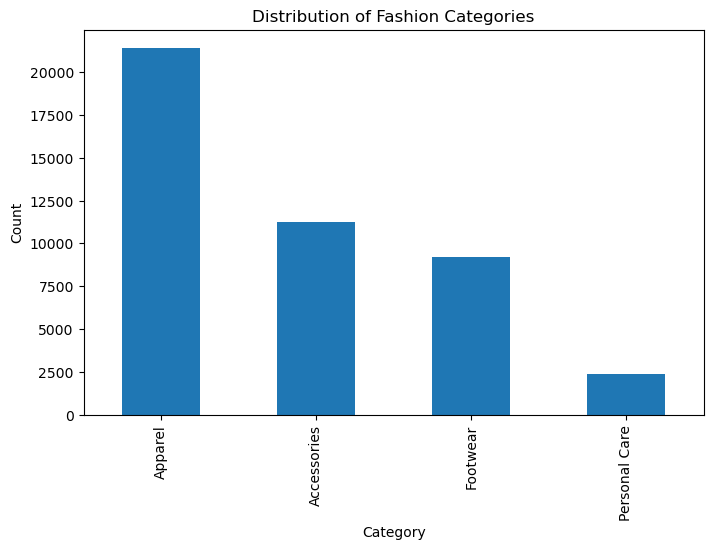

In [7]:
# Category Distribution

plt.figure(figsize=(8,5))

df["masterCategory"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Distribution of Fashion Categories"
)

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

In [8]:
# Image Folder Path
image_folder = r"C:\Study\Artificial Intelligence\Rocommendation Algorithm\images"

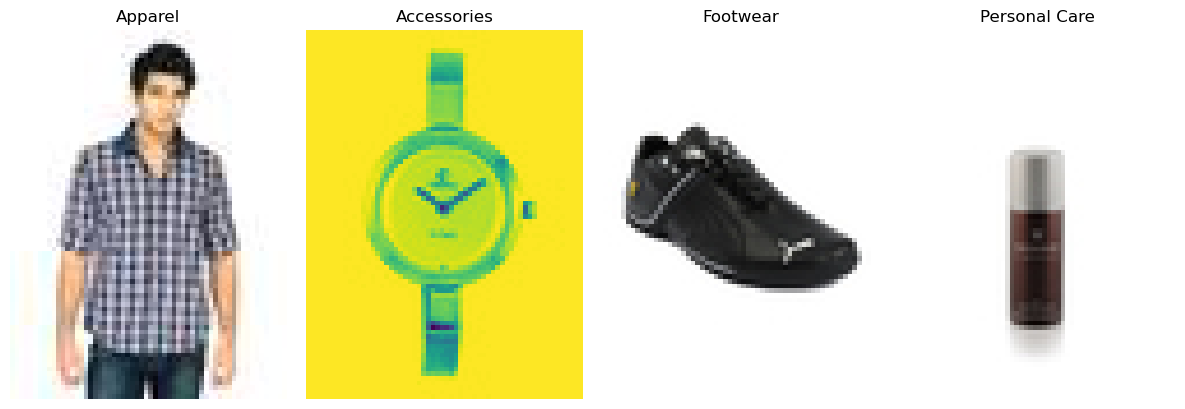

In [9]:
# Sample Images from Each Category
categories = [
    "Apparel",
    "Accessories",
    "Footwear",
    "Personal Care"
]

plt.figure(figsize=(12,4))

for i, category in enumerate(categories):

    sample_row = df[
        df["masterCategory"] == category
    ].iloc[0]

    image_path = os.path.join(
        image_folder,
        str(sample_row["id"]) + ".jpg"
    )

    img = Image.open(image_path)

    plt.subplot(1,4,i+1)

    plt.imshow(img)

    plt.title(category)

    plt.axis("off")

plt.tight_layout()

plt.show()

# 4. Image Loading

To reduce training time, a subset of the dataset is used.

A total of 3000 fashion images are loaded and resized to 128 × 128 pixels for CNN training.

In [10]:
# 4. Image Loading
sample_size = 3000

df_sample = df.sample(
    n=sample_size,
    random_state=42
).reset_index(drop=True)

print("Sample Shape:", df_sample.shape)

Sample Shape: (3000, 11)


In [11]:
# Load Images

images = []
labels = []

image_folder = r"C:\Study\Artificial Intelligence\Rocommendation Algorithm\images"

for _, row in df_sample.iterrows():

    image_path = os.path.join(
        image_folder,
        str(row["id"]) + ".jpg"
    )

    if os.path.exists(image_path):

        try:

            img = Image.open(
                image_path
            ).convert("RGB")

            img = img.resize(
                (128, 128)
            )

            img = np.array(img) / 255.0

            images.append(img)

            labels.append(
                row["label"]
            )

        except:
            pass

X = np.array(images)

y = np.array(labels)

print("X Shape:", X.shape)

print("y Shape:", y.shape)

X Shape: (2998, 128, 128, 3)
y Shape: (2998,)


# 5. Train-Test Split

The dataset is divided into training and testing sets.

80% of the images are used for training and 20% are used for evaluation.

In [12]:
# 5. Train-Test Split

from tensorflow.keras.utils import to_categorical

y_cat = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2398, 128, 128, 3)
X_test : (600, 128, 128, 3)
y_train: (2398, 4)
y_test : (600, 4)


# 6. CNN Architecture

A Convolutional Neural Network (CNN) is constructed for fashion image classification.

The architecture contains:

- Two convolution layers
- Two max-pooling layers
- One fully connected layer
- Dropout regularization
- Softmax output layer

In [13]:
# 6. CNN Architecture

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu',
        name='embedding_layer'
    ),

    Dropout(0.5),

    Dense(
        4,
        activation='softmax'
    )
])

model.summary()

C:\Users\garli\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_layer (Dense)              │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 28,228 (110.27 KB)

 Trainable params: 28,228 (110.27 KB)

 Non-trainable params: 0 (0.00 B)

# 7. Baseline CNN Training

The CNN model is trained using the Adam optimizer.

The baseline configuration is:

- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: 32
- Epochs: 40
- Dropout: 0.5

This model serves as the reference for subsequent parameter tuning experiments.

In [14]:
# Baseline Optimizer
from tensorflow.keras.optimizers import Adam

adam = Adam(
    learning_rate=0.001
)

In [15]:
# Compile Model
model.compile(

    optimizer=adam,

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [16]:
# Train Baseline CNN

history = model.fit(

    X_train,

    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=40,

    batch_size=32,

    verbose=1
)

Epoch 1/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.4654 - loss: 1.2280 - val_accuracy: 0.4817 - val_loss: 1.1865
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.4829 - loss: 1.1799 - val_accuracy: 0.4817 - val_loss: 1.1402
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.4937 - loss: 1.0970 - val_accuracy: 0.5167 - val_loss: 1.0232
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.5575 - loss: 1.0075 - val_accuracy: 0.5133 - val_loss: 0.9965
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.6068 - loss: 0.9277 - val_accuracy: 0.6700 - val_loss: 0.8588
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.6526 - loss: 0.8480 - val_accuracy: 0.6933 - val_loss: 0.7958
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.6793 - loss: 0.7923 - val_accuracy: 0.6950 - val_loss: 0.7651
Epoch 8/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.7106 - loss: 0.7675 - val_accuracy: 0.70

In [17]:
# Final Results
print(
    "Final Training Accuracy:",
    history.history['accuracy'][-1]
)

print(
    "Final Validation Accuracy:",
    history.history['val_accuracy'][-1]
)

Final Training Accuracy: 0.7935779690742493
Final Validation Accuracy: 0.7300000190734863


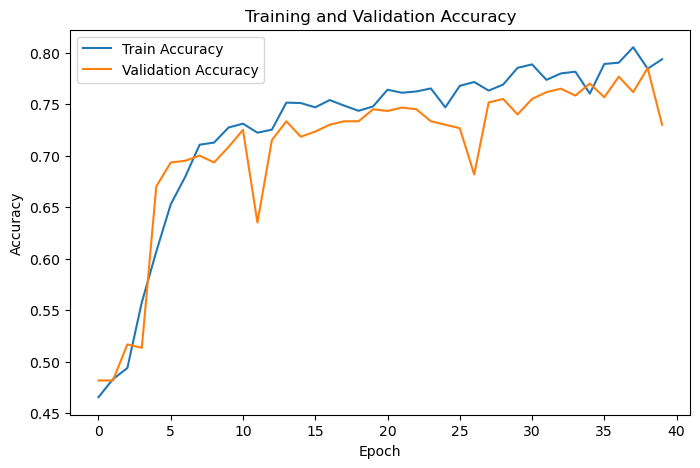

In [18]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()

plt.show()

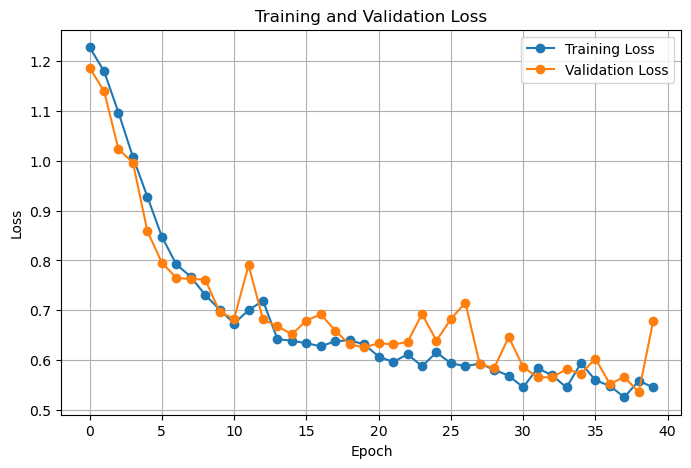

In [19]:
# Training and Validation Loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    marker='o',
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    marker='o',
    label='Validation Loss'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

# 8. Experiment 1 – Dropout Effect

This experiment evaluates the impact of dropout regularization.

All training parameters remain unchanged except for the dropout layer.

The results are compared with the baseline CNN model.

In [20]:
# Experiment 1 - CNN without Dropout

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense
)

model_no_dropout = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu',
        name='embedding_layer'
    ),

    Dense(
        4,
        activation='softmax'
    )
])

model_no_dropout.summary()

C:\Users\garli\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_layer (Dense)              │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 28,228 (110.27 KB)

 Trainable params: 28,228 (110.27 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Compile
from tensorflow.keras.optimizers import Adam

adam = Adam(
    learning_rate=0.001
)

model_no_dropout.compile(

    optimizer=adam,

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [22]:
# Train

history_no_dropout = model_no_dropout.fit(

    X_train,

    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=40,

    batch_size=32,

    verbose=1
)

Epoch 1/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.4783 - loss: 1.2155 - val_accuracy: 0.4817 - val_loss: 1.1854
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.4812 - loss: 1.1414 - val_accuracy: 0.5117 - val_loss: 1.0764
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.5200 - loss: 1.0442 - val_accuracy: 0.5500 - val_loss: 1.0041
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.5425 - loss: 1.0039 - val_accuracy: 0.5850 - val_loss: 0.9671
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.5892 - loss: 0.9432 - val_accuracy: 0.5750 - val_loss: 0.9419
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.6364 - loss: 0.8945 - val_accuracy: 0.6200 - val_loss: 0.8763
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.6835 - loss: 0.8145 - val_accuracy: 0.6933 - val_loss: 0.8145
Epoch 8/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.6881 - loss: 0.7748 - val_accuracy: 0.7067 - v

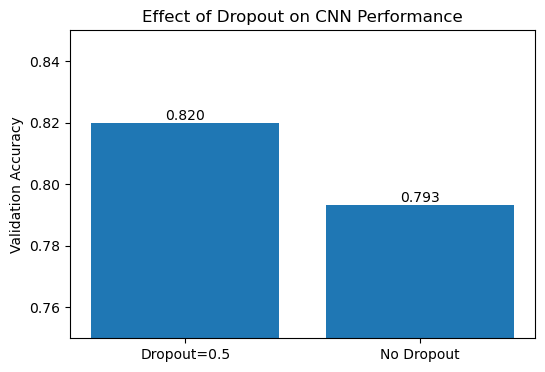

In [23]:
models = [
    "Dropout=0.5",
    "No Dropout"
]

acc = [
    0.8200,
    0.7933
]

plt.figure(figsize=(6,4))

bars = plt.bar(models, acc)

plt.ylabel("Validation Accuracy")

plt.title(
    "Effect of Dropout on CNN Performance"
)

plt.ylim(0.75,0.85)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.001,
        f"{bar.get_height():.3f}",
        ha='center'
    )

plt.show()

# 9. Experiment 2 – Adam vs SGD

This experiment compares two optimization algorithms:

- Adam
- SGD

All other parameters remain unchanged.

The objective is to determine which optimizer learns fashion image features more effectively.

In [24]:
# SGD Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

model_sgd = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu',
        name='embedding_layer'
    ),

    Dropout(0.5),

    Dense(
        4,
        activation='softmax'
    )
])

C:\Users\garli\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
# SGD Optimizer
from tensorflow.keras.optimizers import SGD

sgd = SGD(
    learning_rate=0.001
)

model_sgd.compile(

    optimizer=sgd,

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [26]:
# Train SGD Model
history_sgd = model_sgd.fit(

    X_train,

    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=40,

    batch_size=32,

    verbose=1
)

Epoch 1/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.2840 - loss: 1.3741 - val_accuracy: 0.4700 - val_loss: 1.3193
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.3857 - loss: 1.3101 - val_accuracy: 0.4817 - val_loss: 1.2827
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.4320 - loss: 1.2835 - val_accuracy: 0.4817 - val_loss: 1.2610
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.4575 - loss: 1.2690 - val_accuracy: 0.4817 - val_loss: 1.2458
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.4658 - loss: 1.2536 - val_accuracy: 0.4817 - val_loss: 1.2336
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.4708 - loss: 1.2436 - val_accuracy: 0.4817 - val_loss: 1.2247
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.4679 - loss: 1.2438 - val_accuracy: 0.4817 - val_loss: 1.2186
Epoch 8/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.4658 - loss: 1.2355 - val_accuracy: 0.4817 -

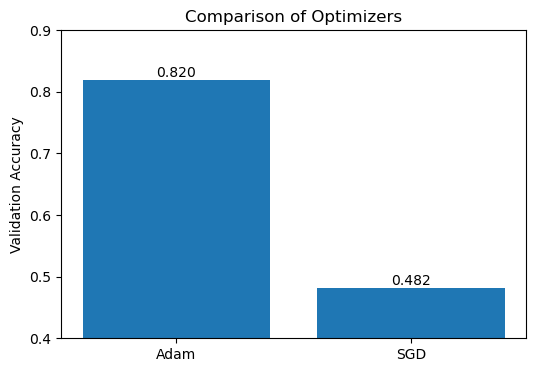

In [27]:
optimizers = [
    "Adam",
    "SGD"
]

acc = [
    0.8200,
    0.4817
]

plt.figure(figsize=(6,4))

bars = plt.bar(
    optimizers,
    acc
)

plt.ylabel(
    "Validation Accuracy"
)

plt.title(
    "Comparison of Optimizers"
)

plt.ylim(0.4,0.9)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.005,
        f"{bar.get_height():.3f}",
        ha='center'
    )

plt.show()

# 10. Feature Extraction

The trained CNN model is converted into a feature extractor.

The 128-dimensional embedding layer is used to generate compact visual representations of fashion products.

These feature vectors are later used for recommendation through cosine similarity.

In [28]:
# 10. Feature Extraction Model
feature_model = Model(
    inputs=model.layers[0].input,
    outputs=model.get_layer(
        "embedding_layer"
    ).output
)

In [29]:
# Test Feature Extraction

sample_feature = feature_model.predict(
    X_test[:1]
)

print("Feature Shape:",
      sample_feature.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
Feature Shape: (1, 128)


# 11. Generate Feature Embeddings

The trained CNN is used to generate feature vectors for all fashion products.

These embeddings are later compared using cosine similarity to produce recommendations.

In [30]:
# Generate Features

all_features = feature_model.predict(
    X,
    verbose=1
)

print("Feature Matrix Shape:",
      all_features.shape)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step
Feature Matrix Shape: (2998, 128)


# 12. Recommendation Generation

Cosine similarity is used to compare feature vectors.

Products with the highest similarity scores are recommended as visually similar fashion items.

In [31]:
# Cosine Similarity Matrix
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    all_features
)

print(
    "Similarity Matrix Shape:",
    similarity_matrix.shape
)

Similarity Matrix Shape: (2998, 2998)


In [32]:
# Recommendation Function
def recommend_items(
    query_index,
    top_n=5
):

    similarity_scores = similarity_matrix[
        query_index
    ]

    similar_indices = np.argsort(
        similarity_scores
    )[::-1]

    recommended = similar_indices[
        1:top_n+1
    ]

    return recommended

In [33]:
query_index = 2000

recommendations = recommend_items(
    query_index,
    top_n=5
)

print(
    "Recommended Indices:"
)

print(recommendations)

Recommended Indices:
[1870  169 1263 1070   90]


# 13. Recommendation Visualisation

The recommendation system is evaluated visually.

A query image and its top five recommended products are displayed to assess recommendation quality.

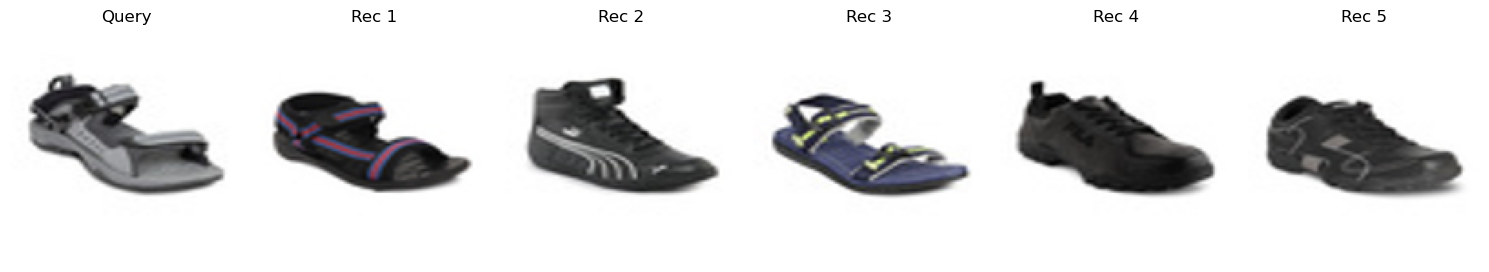

In [34]:
# Recommendation Visualisation
query_index = 2000

recommended = recommend_items(
    query_index,
    top_n=5
)

plt.figure(figsize=(15,4))

# Query Image
plt.subplot(1,6,1)

plt.imshow(X[query_index])

plt.title("Query")

plt.axis("off")

# Recommended Images
for i, idx in enumerate(recommended):

    plt.subplot(1,6,i+2)

    plt.imshow(X[idx])

    plt.title(f"Rec {i+1}")

    plt.axis("off")

plt.tight_layout()

plt.show()